In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [92]:
df = pd.read_csv(r"C:\Users\Soumyadip Saha\Downloads\Salary_Data.csv")

In [93]:
df.head() # First 5v rows

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [94]:
df.tail()  # Last 5 rows

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [95]:
df.shape  # Dataset Size

(30, 2)

In [96]:
df.columns   # Column Names

Index(['YearsExperience', 'Salary'], dtype='object')

In [97]:
df.info()  # Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [98]:
df.describe()   #  Statistical Summary

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [99]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [100]:
# Feature (X) এবং Target (y) আলাদা 

In [101]:
x=df[['YearsExperience']]  #df['YearsExperience'] → Series (1D) df[['YearsExperience']] → DataFrame (2D)
y=df['Salary']

In [102]:
x.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [103]:
y.head()

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64

In [104]:
#Dataset-কে দুই ভাগে ভাগ করব। 80% → Train 20% → Test

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [106]:
X_train.shape

(24, 1)

In [107]:
X_test.shape

(6, 1)

In [108]:
# 24 train 6 test

In [109]:
model=LinearRegression()

In [110]:
model.fit(X_train, y_train)  # এখন model best-fit line শিখে নেবে।

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [111]:
y_pred=model.predict(X_test) # এখন y_pred-এ predicted salary থাকবে।

In [112]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [113]:
result = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

result

,Actual Salary,Predicted Salary
27,112635.0,115790.210113
15,67938.0,71498.278095
23,113812.0,102596.868661
17,83088.0,75267.804224
8,64445.0,55477.792045
9,57189.0,60189.699707


In [114]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print(r2)

0.9024461774180498


In [115]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [116]:
mae = mean_absolute_error(y_test, y_pred)
print(mae)

6286.453830757742


In [117]:
mse=mean_squared_error(y_test,y_pred)

In [118]:
rmse=np.sqrt(mse)
print(rmse)

7059.043621901506


In [132]:
# Regression Line Plot

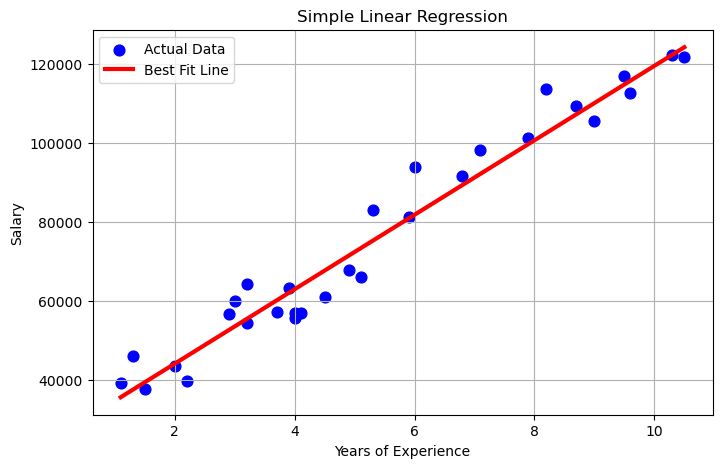

In [134]:
plt.figure(figsize=(8,5))

plt.scatter(x, y, color='blue', s=60, label='Actual Data')

plt.plot(x, model.predict(x),
         color='red',
         linewidth=3,
         label='Best Fit Line')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")
plt.grid(True)
plt.legend()

plt.show()

In [135]:
experience = [[5.5]]

salary = model.predict(experience)

print(salary)

[77152.56728845]


C:\Users\Soumyadip Saha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
